Here, I will demonstrate how we run simulations with self-gravity.

In [1]:
from galpy.potential import PlummerPotential
from galpy.df import isotropicPlummerdf
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from tambora.util import galpydfsampler
from tambora.simulation import Simulation

# Add particles

In [2]:
import multiprocessing as mp
mp.cpu_count()

10

In [2]:
pot = PlummerPotential(amp=1e10*u.Msun, b=2*u.kpc)
df = isotropicPlummerdf(pot=pot)
pos, vel, masses = galpydfsampler(df, n=10000, m_total=1e10)

Text(0.5, 1.0, 'Isotropic Hernquist DF Sampling')

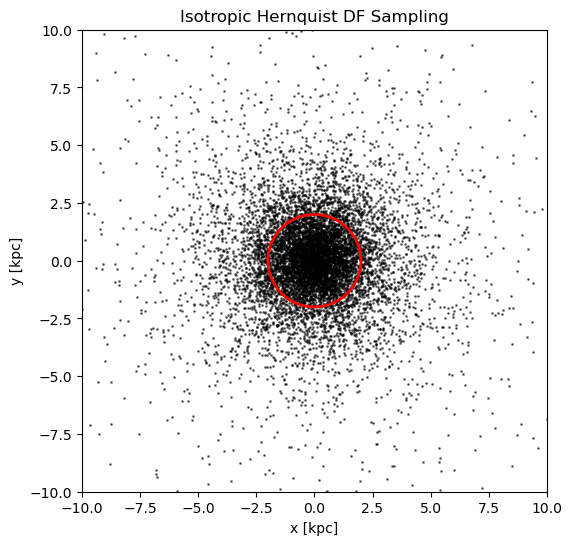

In [3]:
plt.figure(figsize=(6,6))
plt.scatter(pos[:,0], pos[:,1], s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
plt.gca().add_artist(circle)
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.title('Isotropic Hernquist DF Sampling')

In [4]:
from tambora.simulation import Simulation
sim = Simulation()
sim.add_particles('stars', pos, vel, mass=masses)

# Running the simulation

In [5]:
sim.run(t_end=100, dt=0.1, dt_out=10, eps=0.6)

NameError: name 'sim' is not defined

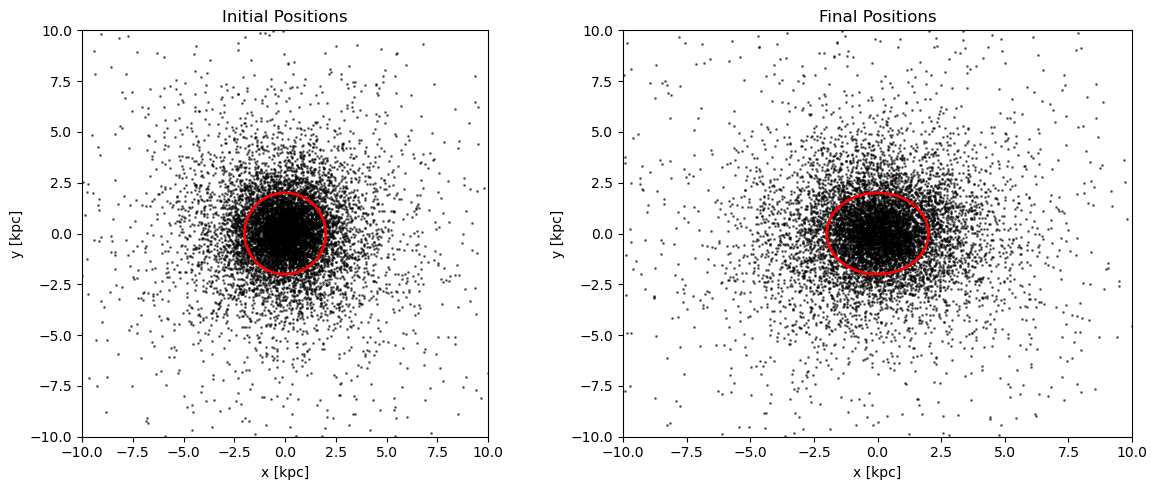

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Initial positions
axes[0].scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
axes[0].add_artist(circle)
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(-10, 10)
axes[0].set_xlabel('x [kpc]')
axes[0].set_ylabel('y [kpc]')
axes[0].set_title('Initial Positions')
axes[0].set_aspect('equal')

# Final positions

axes[1].scatter(sim.x(-1), sim.y(-1), s=1, c='k', alpha=0.5)
circle = plt.Circle((0, 0), 2, color='r', fill=False, label='Scale Radius', lw=2)
axes[1].add_artist(circle)
axes[1].set_xlim(-10, 10)
axes[1].set_ylim(-10, 10)
axes[1].set_xlabel('x [kpc]')
axes[1].set_ylabel('y [kpc]')
axes[1].set_title('Final Positions')

plt.tight_layout()
plt.show()

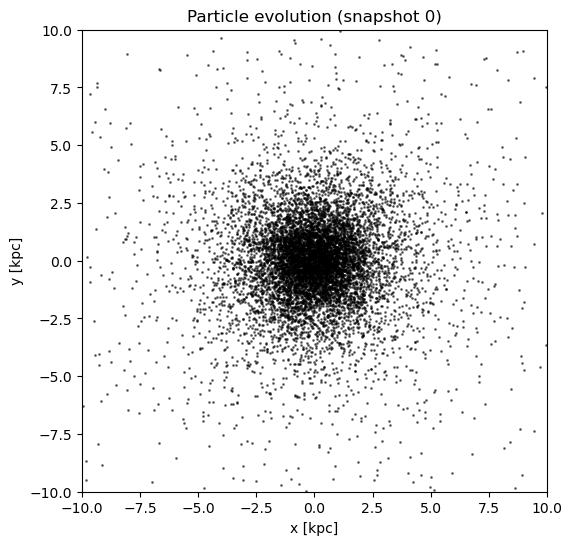

In [43]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

n_frames = 11  # t_end=100, dt_out=10 -> snapshots at 0,10,...,100

fig_anim, ax_anim = plt.subplots(figsize=(6, 6))
sc = ax_anim.scatter(sim.x(0), sim.y(0), s=1, c='k', alpha=0.5)

ax_anim.set_xlim(-10, 10)
ax_anim.set_ylim(-10, 10)
ax_anim.set_xlabel('x [kpc]')
ax_anim.set_ylabel('y [kpc]')
title = ax_anim.set_title('Particle evolution (t = 0)')

def update(i):
    sc.set_offsets(list(zip(sim.x(i), sim.y(i))))
    title.set_text(f'Particle evolution (snapshot {i})')
    return sc, title

anim = FuncAnimation(fig_anim, update, frames=n_frames, interval=250, blit=False)
HTML(anim.to_jshtml())

# Diagnostics

In [8]:
dEs = [np.abs(sim.percent_dE(t2=t)) for t in np.arange(len(sim.times))]

In [ ]:
dEs = [np.abs(sim.percent_dE(t2=t)) for t in np.arange(len(sim.times))]

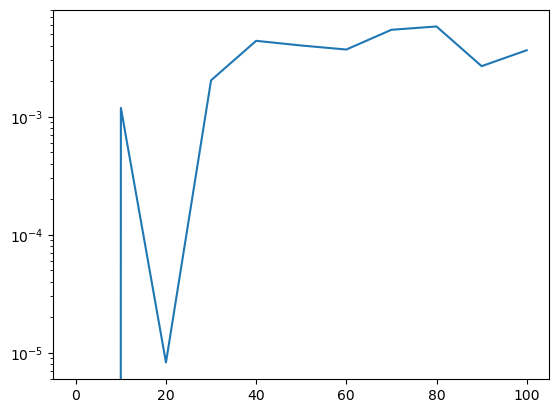

In [9]:
plt.plot(sim.times, dEs)
plt.yscale('log')